In [1]:
# Installation and set up
!pip install kagglehub[pandas-datasets]


In [2]:
# Imports
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
import math

In [3]:
# Set the path to the file you'd like to load
file_path = "cleaned_canada.csv"

# Load the latest version
original_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yuliiabulana/canada-housing",
  file_path,
)

original_df.head()

,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,...,Exterior,Fireplace,Heating,Flooring,Roof,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,...,NaN,No,heat pump,carpet,NaN,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,...,NaN,No,heat pump,NaN,NaN,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,...,Metal,No,NaN,laminate,tar,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,...,NaN,Yes,forced air,NaN,NaN,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,...,NaN,No,radiant,NaN,NaN,No,none,No,No,No


In [4]:
original_df.describe()

,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Square Footage
count,44896.000000,44896.000000,4.489600e+04,44896.000000,44896.000000,44896.000000,44896.000000
mean,49.010267,-106.632760,1.070457e+06,3.214919,2.522652,2.485950,1787.726323
std,2.659066,22.270395,1.442961e+06,1.636517,1.423765,86.626599,1988.320406
min,42.045940,-135.856018,5.000000e+04,0.000000,0.000000,0.000000,140.000000
25%,48.477511,-122.887882,3.999900e+05,2.000000,2.000000,0.000000,975.000000
50%,49.217891,-119.395219,6.880000e+05,3.000000,2.000000,0.060000,1417.000000
75%,49.927914,-102.485638,1.200000e+06,4.000000,3.000000,0.180000,2198.000000
max,65.281488,-52.668600,5.880000e+07,37.000000,26.000000,8600.000000,290034.000000


# 1. Data Preparation

In this step, we scale/normalize and prepare the data for any kind of training. We maintain a referenced to the original df as well as the corresponding normalized/scaled df which is will be used for training. We'll try and keep the original df in sync with normalized df by performing the similar operations. The original df is better suited for exploration, visualization and reasoning.

In [5]:
# Constants
TARGET = 'Price'
TEST_SPLIT_RATIO = 0.2
RANDOM_STATE = 42
IQR_MULTIPLIER = 3
KMEANS_CLUSTER_RANGE = range(2, 15, 2)

# Feature Definitions
CATEGORICAL_COLS = [
    'City',
    'Province',
    'Property Type',
    'Basement',
    'Exterior',
    'Heating',
    'Flooring',
    'Roof',
    'Sewer'
]

NUMERIC_COLS = [
    'Bedrooms',
    'Bathrooms',
    'Square Footage',
    'Acreage',
    'Latitude',
    'Longitude'
]

BINARY_COLS = [
    'Garage',
    'Parking',
    'Fireplace',
    'Waterfront',
    'Pool',
    'Garden',
    'Balcony'
]
BINARY_MAP = {'Yes': 1, 'No': 0}

## 1.1 Function Definitions

In [6]:
# Function Definitions

def map_binary_cols(df):
  """Replace Yes/No values with 1/0 for binary columns."""
  for col in BINARY_COLS:
      if col in df.columns:
          df[col] = df[col].map(BINARY_MAP)
  return df

def one_hot_encode_categorical_cols(df):
  """One-hot encode categorical columns. Returns (df, new_columns)."""
  before_cols = set(df.columns)
  df = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)
  new_cols = [col for col in df.columns if col not in before_cols]
  return df, new_cols

def add_interaction_terms(df):
  """Add interaction and derived features. Returns (df, new_columns)."""
  df['sqft_per_bedroom'] = df['Square Footage'] / (df['Bedrooms'] + 1)
  df['bath_bed_ratio'] = df['Bathrooms'] / (df['Bedrooms'] + 1)
  df['sqft_x_bedrooms'] = df['Square Footage'] * df['Bedrooms']
  df['sqft_x_bathrooms'] = df['Square Footage'] * df['Bathrooms']
  df['luxury_score'] = (
      df['Fireplace'] + df['Waterfront'] +
      df['Pool'] + df['Garden'] + df['Balcony']
  )
  new_cols = [
      'sqft_per_bedroom',
      'bath_bed_ratio',
      'sqft_x_bedrooms',
      'sqft_x_bathrooms',
      'luxury_score'
  ]
  return df, new_cols

def add_polynomial_features(df):
  """Add polynomial features for key numeric columns. Returns (df, new_columns)."""
  poly = PolynomialFeatures(degree=2, include_bias=False)
  poly_features = df[['Square Footage', 'Bedrooms', 'Bathrooms']]
  poly_data = poly.fit_transform(poly_features)
  poly_cols = poly.get_feature_names_out()
  poly_cols = [col.replace(' ', '_').replace('^', '_pow_') for col in poly_cols]
  poly_df = pd.DataFrame(poly_data, columns=poly_cols, index=df.index)
  df = pd.concat([df, poly_df], axis=1)
  return df, list(poly_cols)

def get_scaled_df(df):
  """Standard scale all numeric columns."""
  numeric_columns = df.select_dtypes(include=[np.number]).columns
  scaler = StandardScaler()
  df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
  return df

def remove_outliers_iqr(df, columns, multiplier=IQR_MULTIPLIER):
  """Remove outliers using IQR method. Returns (clean_df, mask)."""
  subset = df[columns]
  q1 = subset.quantile(0.25)
  q3 = subset.quantile(0.75)
  iqr = q3 - q1
  lower = q1 - multiplier * iqr
  upper = q3 + multiplier * iqr
  mask = pd.Series(True, index=df.index)
  for col in columns:
      mask &= (df[col] >= lower[col]) & (df[col] <= upper[col])
  return df[mask].copy(), mask

def evaluate_regression(y_true, y_pred, verbose=True):
  """Compute regression metrics. Returns dict with mse and r2."""
  mse = mean_squared_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  if verbose:
      print(f'MSE: {mse}')
      print(f'R2: {r2}')
  return {'mse': mse, 'r2': r2}

def get_normalized_df(source_df):
  """Apply full preprocessing pipeline. Returns (df, new_columns)."""
  df = source_df.copy()
  new_cols = []
  df = map_binary_cols(df)
  df, encoded_cols = one_hot_encode_categorical_cols(df)
  new_cols.extend(encoded_cols)
  df, interaction_cols = add_interaction_terms(df)
  new_cols.extend(interaction_cols)
  # Polynomial features excluded - too slow
  # df, poly_cols = add_polynomial_features(df)
  # new_cols.extend(poly_cols)
  df = get_scaled_df(df)
  return df, new_cols

In [7]:
normalized_df, engineered_cols = get_normalized_df(original_df.copy())

# Create a reusable 80/20 split 
train_df, test_df = train_test_split(
    normalized_df,
    test_size=TEST_SPLIT_RATIO,
    random_state=RANDOM_STATE
)

# 2. Fill Missing Data

In this step, we're evaluating and using the best model to predict the missing column values and getting rid of of all NaN values.

## 2.1. Determining the best model to use for classification

In [8]:
basement_cols = [col for col in train_df.columns if col == 'Basement' or col.startswith('Basement_')]

if len(basement_cols) == 0:
    raise ValueError("No basement target column found in train_df/test_df")

# If one-hot encoded, use the first basement dummy; otherwise use 'Basement'
classification_target = basement_cols[0]

# Keep only rows where target is available
train_class_df = train_df.dropna(subset=[classification_target]).copy()
test_class_df = test_df.dropna(subset=[classification_target]).copy()

# Features for basement classification (excludes all basement columns to avoid data leakage)
basement_feature_cols = [col for col in train_class_df.columns if col not in basement_cols]

X_train_basement = train_class_df[basement_feature_cols]
X_test_basement = test_class_df[basement_feature_cols]
y_train_basement = train_class_df[classification_target]
y_test_basement = test_class_df[classification_target]

In [9]:
# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_basement, y_train_basement)
lda_preds = lda.predict(X_test_basement)

lda_report = classification_report(y_true=y_test_basement, y_pred=lda_preds, labels=lda.classes_, zero_division=0)
print(lda_report)

              precision    recall  f1-score   support

       False       0.96      0.98      0.97      8440
        True       0.47      0.30      0.36       540

    accuracy                           0.94      8980
   macro avg       0.71      0.64      0.66      8980
weighted avg       0.93      0.94      0.93      8980



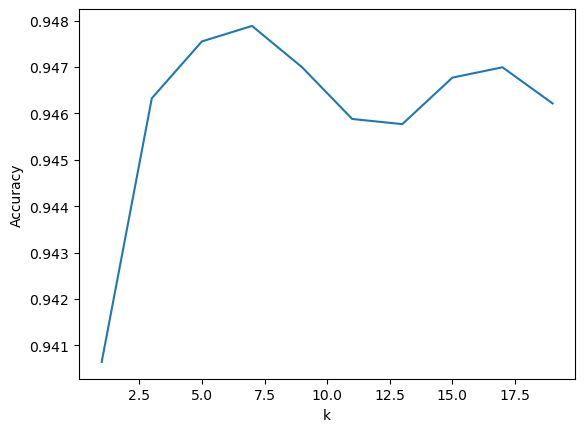


Best k value: 7


In [10]:
# Find the best k value
k_values = range(1, 20, 2)
accs = []

for k in k_values:
  knn_temp = KNeighborsClassifier(k)
  knn_temp.fit(X_train_basement, y_train_basement)
  accs.append(accuracy_score(y_test_basement, knn_temp.predict(X_test_basement)))

plt.plot(k_values, accs)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

best_knn_k = k_values[accs.index(max(accs))]
print('\nBest k value:', best_knn_k)

In [11]:
# KNN with k = best KNN

basement_knn = KNeighborsClassifier(best_knn_k)
basement_knn.fit(X_train_basement, y_train_basement)
knn_preds = basement_knn.predict(X_test_basement)

knn_report = classification_report(y_true=y_test_basement, y_pred=knn_preds, labels=basement_knn.classes_, zero_division=0)
print(knn_report)

              precision    recall  f1-score   support

       False       0.96      0.99      0.97      8440
        True       0.66      0.27      0.38       540

    accuracy                           0.95      8980
   macro avg       0.81      0.63      0.68      8980
weighted avg       0.94      0.95      0.94      8980



In [12]:
# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train_basement, y_train_basement)
logreg_preds = logreg.predict(X_test_basement)

logreg_report = classification_report(y_true=y_test_basement, y_pred=logreg_preds, labels=logreg.classes_, zero_division=0)
print(logreg_report)

              precision    recall  f1-score   support

       False       0.95      0.99      0.97      8440
        True       0.65      0.25      0.36       540

    accuracy                           0.95      8980
   macro avg       0.80      0.62      0.67      8980
weighted avg       0.94      0.95      0.94      8980



/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 2.2 Using KNN classification to predict and fill missing data points

In [35]:
# Get all rows with missing basement values from original_df (before one-hot encoding)
# pd.get_dummies() doesn't preserve NaN - it encodes missing values as all-zeros
missing_basement_indices = original_df[original_df['Basement'].isna()].index
missing_basement_df = normalized_df.loc[missing_basement_indices].copy()

print(f'Found {len(missing_basement_df)} rows with missing basement values.')

# Align to model feature schema and predict
X_missing = missing_basement_df.reindex(columns=basement_feature_cols, fill_value=0)
basement_preds = basement_knn.predict(X_missing)

# Merge with original dataframe
imputed_df = normalized_df.copy()
imputed_df.loc[missing_basement_indices, classification_target] = basement_preds

# Verify imputation
print('Imputed values distribution:', pd.Series(basement_preds).value_counts().to_dict())
print('Row count preserved:', normalized_df.index.size == imputed_df.index.size)

Found 29934 rows with missing basement values.
Imputed values distribution: {False: 29791, True: 143}
Row count preserved: True


# 3. Pre-training

## 3.1 Find outliers for too expensive or too big houses

In [14]:
# Extracting features for outlier detection

OUTLIER_FEATURES = ['Square Footage', 'Price']

outlier_subset = imputed_df[OUTLIER_FEATURES]

outlier_subset.head()

,Square Footage,Price
0,-0.451002,-0.160406
1,0.046911,0.055126
2,-0.440440,-0.638594
3,1.300747,0.157694
4,-0.268434,-0.215224


In [15]:
outlier_subset.describe()

,Square Footage,Price
count,4.489600e+04,4.489600e+04
mean,-2.152392e-17,2.025781e-17
std,1.000011e+00,1.000011e+00
min,-8.287118e-01,-7.072041e-01
25%,-4.087547e-01,-4.646516e-01
50%,-1.864541e-01,-2.650528e-01
75%,2.063441e-01,8.977706e-02
max,1.449713e+02,4.000814e+01


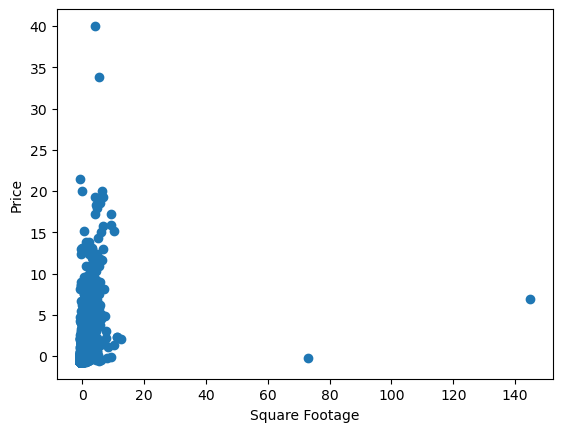

In [16]:
# Exploring the outlier features

plt.scatter(outlier_subset[OUTLIER_FEATURES[0]], outlier_subset[OUTLIER_FEATURES[1]])
plt.xlabel(OUTLIER_FEATURES[0])
plt.ylabel(OUTLIER_FEATURES[1])
plt.show()

The data has extreme outliers in terms of square footage and pricing that can affect training. Even scaling will not work because it will push most of the data within a small range.

To get rid of outliers, we'll be using the IQR (inter quartile range) method with a 3x IQR cutoff.

In [17]:
# Remove outliers using the IQR helper function

clean_df, outlier_mask = remove_outliers_iqr(imputed_df, OUTLIER_FEATURES)
outlier_subset_clean = outlier_subset[outlier_mask].copy()

outlier_subset_clean.describe()

,Square Footage,Price
count,42973.000000,42973.000000
mean,-0.076177,-0.146482
std,0.472341,0.469246
min,-0.828712,-0.707204
25%,-0.416299,-0.466031
50%,-0.206572,-0.285151
75%,0.146997,0.020405
max,2.051138,1.753042


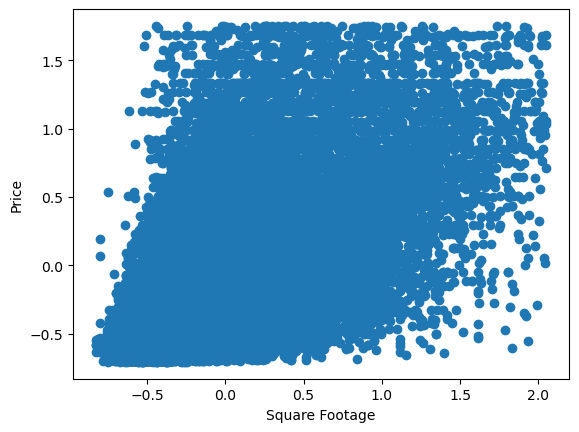

In [18]:
# Plotting the clean data after removing outliers

plt.scatter(outlier_subset_clean[OUTLIER_FEATURES[0]], outlier_subset_clean[OUTLIER_FEATURES[1]])
plt.xlabel(OUTLIER_FEATURES[0])
plt.ylabel(OUTLIER_FEATURES[1])
plt.show()

In [19]:
outlier_subset.isna().any()

Square Footage    False
Price             False
dtype: bool

In [20]:
outlier_subset_clean.head()

,Square Footage,Price
0,-0.451002,-0.160406
1,0.046911,0.055126
2,-0.440440,-0.638594
3,1.300747,0.157694
4,-0.268434,-0.215224


## 3.2. Using Clustering to divide data into similar areas

To avoid the curse of dimensionality, we limit clustering to geographic features (Latitude and Longitude). Location-based clustering groups properties into coherent geographic regions where local market conditions, neighborhood characteristics, and proximity-based factors naturally influence pricing. This allows us to train separate price prediction models per region, capturing location-specific price dynamics.

In [21]:
# Training multiple clustering models to find best k
CLUSTERING_FEATURES = ['Latitude', 'Longitude']

clustering_subset = clean_df[CLUSTERING_FEATURES]
kmeans_models = []

for n_clusters in KMEANS_CLUSTER_RANGE:
  km = KMeans(n_clusters=n_clusters, n_init='auto')
  km.fit(clustering_subset)
  kmeans_models.append(km)

len(kmeans_models)

7

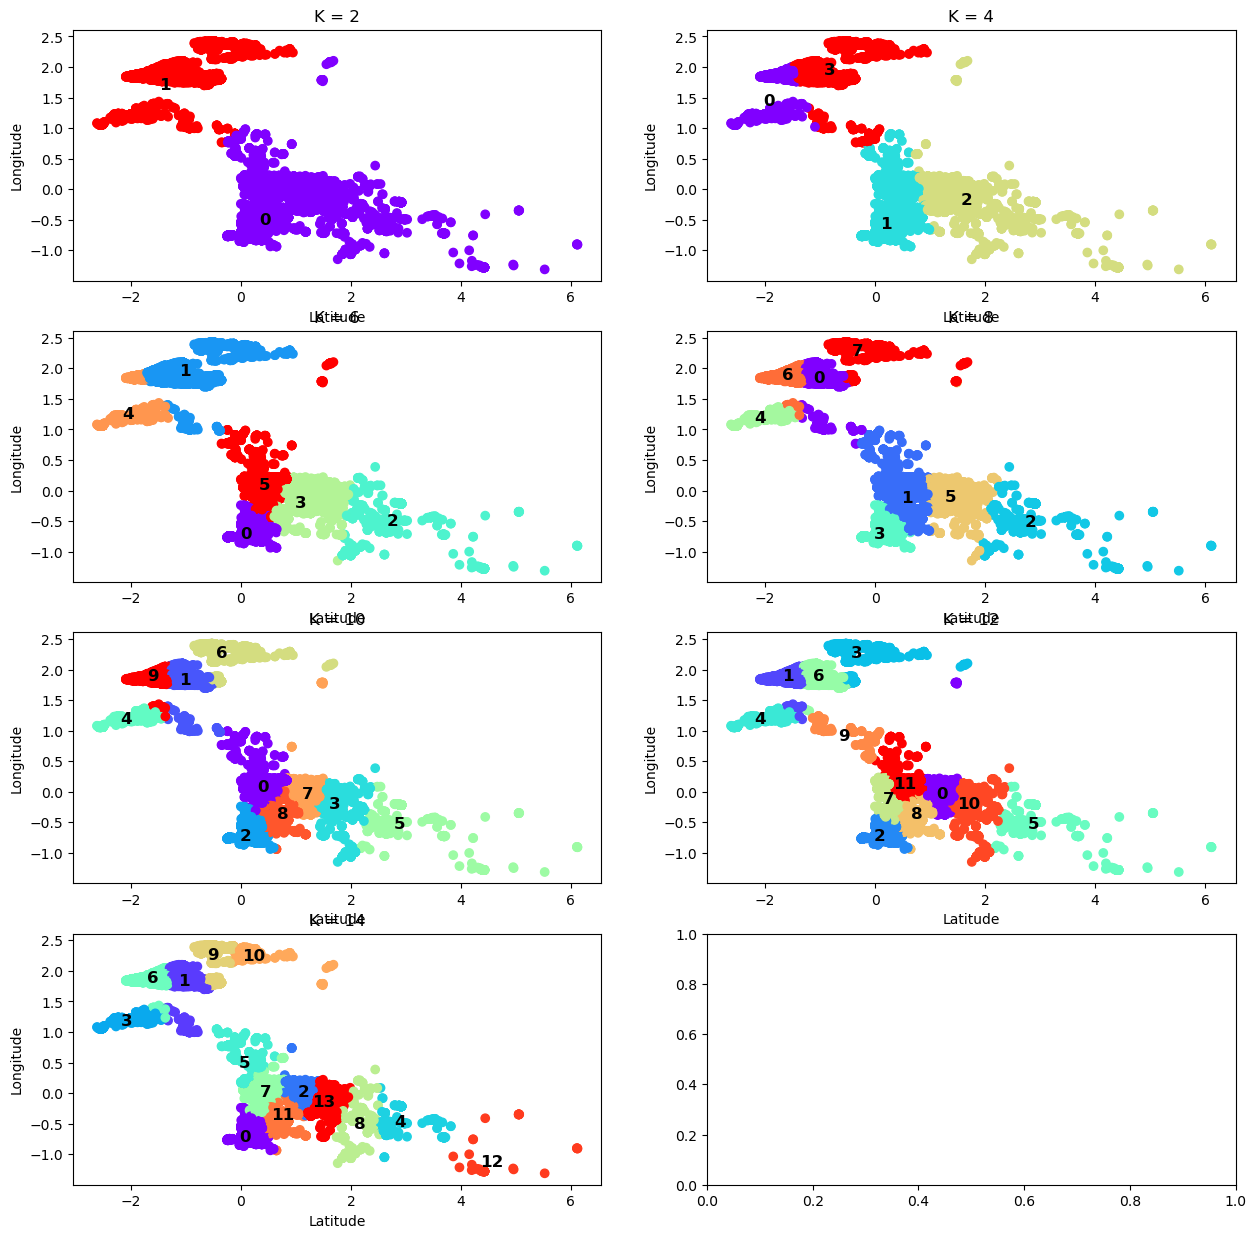

In [22]:
# Plotting models side by side

n_cols = 2
n_rows = math.ceil(len(kmeans_models) / n_cols)

fig, axs = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(15, 15))

for i, km in enumerate(kmeans_models):
  row = i // n_cols
  col = i % n_cols
  ax = axs[row][col]
  ax.scatter(clustering_subset[CLUSTERING_FEATURES[0]], clustering_subset[CLUSTERING_FEATURES[1]], c=km.labels_, cmap='rainbow')
  ax.set_title(f'K = {km.n_clusters}')
  ax.set_xlabel(CLUSTERING_FEATURES[0])
  ax.set_ylabel(CLUSTERING_FEATURES[1])
  centers = km.cluster_centers_
  for cluster_id, center in enumerate(centers):
    ax.text(center[0], center[1], str(cluster_id), fontsize=12, fontweight='bold', ha='center', va='center')

In [23]:
# Select the model with most clusters

selected_kmeans = kmeans_models[-1]

clustered_df = clean_df.copy()
clustered_df['cluster'] = selected_kmeans.labels_

clustered_df.head()

,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Square Footage,Garage,Parking,Fireplace,...,Sewer_municipal,Sewer_none,Sewer_private,Sewer_septic,sqft_per_bedroom,bath_bed_ratio,sqft_x_bedrooms,sqft_x_bathrooms,luxury_score,cluster
0,0.739485,-0.518200,-0.160406,-0.131328,-0.367096,-0.028698,-0.451002,0.64866,1.178332,-0.841378,...,True,False,False,False,-0.140385,-0.432063,-0.383595,-0.410119,-0.805428,11
1,0.173598,-0.455203,0.055126,-0.131328,-0.367096,-0.025004,0.046911,0.64866,1.178332,-0.841378,...,False,False,False,True,0.034662,-0.432063,-0.128424,-0.212352,-0.805428,0
2,0.306488,-0.582416,-0.638594,-0.742389,-1.069467,-0.028698,-0.440440,-1.54164,-0.848657,-0.841378,...,True,False,False,False,-0.082920,-1.201813,-0.456537,-0.497017,-0.805428,0
3,0.305221,-0.576888,0.157694,1.090793,1.037646,-0.020732,1.300747,0.64866,-0.848657,1.188527,...,True,False,False,False,0.217666,0.337688,1.265737,1.159431,0.770193,0
4,0.079505,-0.716829,-0.215224,-0.131328,-0.367096,-0.028698,-0.268434,0.64866,1.178332,-0.841378,...,False,True,False,False,-0.076201,-0.432063,-0.290032,-0.337605,-0.805428,0


In [24]:
clustered_houses = {
    cluster_id: group_df
    for cluster_id, group_df in clustered_df.groupby('cluster')
}

# 4. Training

## 4.1 Feature Engineering to find the best features for house price prediction

In [25]:
# Use full normalized dataset for feature engineering comparison

X_features = normalized_df.drop(columns=[TARGET])
y_target = normalized_df[TARGET]

X_features.head()

,Latitude,Longitude,Bedrooms,Bathrooms,Acreage,Square Footage,Garage,Parking,Fireplace,Waterfront,...,Roof_wood,Sewer_municipal,Sewer_none,Sewer_private,Sewer_septic,sqft_per_bedroom,bath_bed_ratio,sqft_x_bedrooms,sqft_x_bathrooms,luxury_score
0,0.739485,-0.518200,-0.131328,-0.367096,-0.028698,-0.451002,0.64866,1.178332,-0.841378,-0.058859,...,False,True,False,False,False,-0.140385,-0.432063,-0.383595,-0.410119,-0.805428
1,0.173598,-0.455203,-0.131328,-0.367096,-0.025004,0.046911,0.64866,1.178332,-0.841378,-0.058859,...,False,False,False,False,True,0.034662,-0.432063,-0.128424,-0.212352,-0.805428
2,0.306488,-0.582416,-0.742389,-1.069467,-0.028698,-0.440440,-1.54164,-0.848657,-0.841378,-0.058859,...,False,True,False,False,False,-0.082920,-1.201813,-0.456537,-0.497017,-0.805428
3,0.305221,-0.576888,1.090793,1.037646,-0.020732,1.300747,0.64866,-0.848657,1.188527,-0.058859,...,False,True,False,False,False,0.217666,0.337688,1.265737,1.159431,0.770193
4,0.079505,-0.716829,-0.131328,-0.367096,-0.028698,-0.268434,0.64866,1.178332,-0.841378,-0.058859,...,False,False,True,False,False,-0.076201,-0.432063,-0.290032,-0.337605,-0.805428


In [26]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_features,
    y_target,
    test_size=TEST_SPLIT_RATIO,
    random_state=RANDOM_STATE
)

In [27]:
feature_sets = {
    "baseline": [
        'Bedrooms', 'Bathrooms', 'Square Footage', 'Acreage'
    ],

    "ratios": [
        'sqft_per_bedroom', 'bath_bed_ratio'
    ],

    "interactions": [
        'sqft_x_bedrooms', 'sqft_x_bathrooms', 'luxury_score'
    ],

    "amenities": [
        'Garden', 'Fireplace', 'Pool', 'Waterfront', 'Balcony'
    ],

    "location": [
        'Latitude', 'Longitude'
    ],
}

# Adding categorical columns dynamically
encoded_cat_cols = [col for col in X_features.columns if any(c in col for c in CATEGORICAL_COLS)]
feature_sets["categorical_full"] = encoded_cat_cols

feature_sets["full_model"] = list(X_features.columns)

In [28]:
# Train and validate each feature set
feature_results = []

for name, features in feature_sets.items():
    model = LinearRegression()
    model.fit(X_train_fe[features], y_train_fe)

    preds = model.predict(X_test_fe[features])
    r2 = r2_score(y_test_fe, preds)

    print(f"'{name}' R2 = {r2}")
    feature_results.append((name, r2))

feature_results_df = pd.DataFrame(feature_results, columns=['Feature Set', 'R2'])
feature_results_df = feature_results_df.sort_values(by='R2', ascending=False)

feature_results_df

'baseline' R2 = -0.013226666198828285
'ratios' R2 = -1.937808934830901
'interactions' R2 = 0.3308636480794509
'amenities' R2 = 0.06199355188888278
'location' R2 = 0.09389936679662636
'categorical_full' R2 = 0.3056784378572548
'full_model' R2 = 0.49701030591649675


,Feature Set,R2
6,full_model,0.497010
2,interactions,0.330864
5,categorical_full,0.305678
4,location,0.093899
3,amenities,0.061994
0,baseline,-0.013227
1,ratios,-1.937809


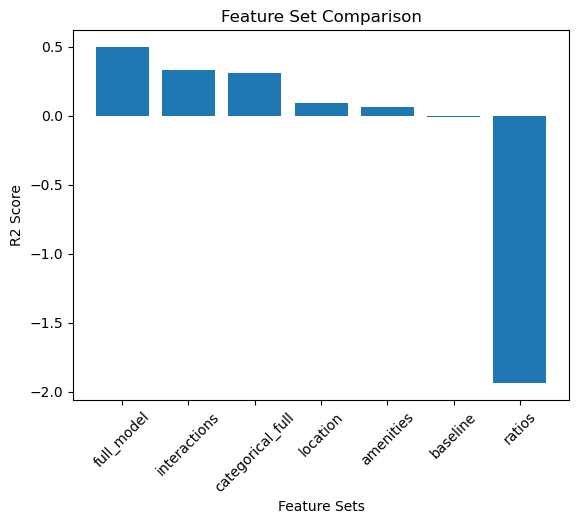

In [29]:
plt.figure()
plt.bar(feature_results_df['Feature Set'], feature_results_df['R2'])
plt.xticks(rotation=45)
plt.xlabel("Feature Sets")
plt.ylabel("R2 Score")
plt.title("Feature Set Comparison")
plt.show()

In [30]:
# Combine best performing feature sets (excluding ratios and full_model)
chosen_features = list(set(
    feature_sets["interactions"]
    + feature_sets["categorical_full"]
    + feature_sets["location"]
    + feature_sets["amenities"]
    + feature_sets["baseline"]
))

model = LinearRegression()
model.fit(X_train_fe[chosen_features], y_train_fe)

preds = model.predict(X_test_fe[chosen_features])
r2 = r2_score(y_test_fe, preds)

print(f"Combined features R2 = {r2}")

Combined features R2 = 0.43411721461107966


## 4.2 Regression on Clusters to build Price Predictor

In [31]:
# Best set of features
best_features = feature_sets["full_model"] # Chosen feature set had less R2 than full model

# Linear Regression applied to each cluster to predict house prices
cluster_price_models = {}
cluster_model_metrics = {}

for cluster_id, cluster_data in clustered_houses.items():
  print(f"\nCluster {cluster_id}")

  # Data is already normalized/scaled upstream
  X_cluster = cluster_data.drop(columns=[TARGET])
  y_cluster = cluster_data[TARGET]

  # Not all clusters may have all cities or features.
  available_features = [col for col in best_features if col in X_cluster.columns]
  if len(available_features) == 0:
      print(f"Skipping cluster {cluster_id}: no chosen features available.")
      continue

  X_cluster_sub = X_cluster[available_features]
  X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(
      X_cluster_sub, y_cluster, test_size=TEST_SPLIT_RATIO, random_state=RANDOM_STATE
  )

  # Train Linear Regression model
  price_model = LinearRegression()
  price_model.fit(X_train_cl, y_train_cl)

  # Predict and evaluate
  y_pred_cl = price_model.predict(X_test_cl)
  metrics = evaluate_regression(y_test_cl, y_pred_cl)

  cluster_price_models[cluster_id] = {'model': price_model, 'features': available_features}
  cluster_model_metrics[cluster_id] = metrics


Cluster 0
MSE: 0.07091998569355969
R2: 0.7023022378728807

Cluster 1
MSE: 0.014682838359183572
R2: 0.45804392260032345

Cluster 2
MSE: 0.019396978170863333
R2: 0.5973434622655917

Cluster 3
MSE: 0.03629140149971284
R2: 0.6576939566607949

Cluster 4
MSE: 0.01926902097726143
R2: 0.36878995312179086

Cluster 5
MSE: 0.02291057242545504
R2: 0.3213810239953476

Cluster 6
MSE: 0.02626940451956888
R2: 0.5277456026267118

Cluster 7
MSE: 0.01083830601880482
R2: 0.6829019062918357

Cluster 8
MSE: 44.55530195499438
R2: -608.5320826801337

Cluster 9
MSE: 0.01131026729923888
R2: 0.39911897646919736

Cluster 10
MSE: 0.013460439068656953
R2: 0.3888756236036809

Cluster 11
MSE: 0.03637712655701142
R2: 0.6579861348635266

Cluster 12
MSE: 0.7685115740509462
R2: -2.7270428232682167

Cluster 13
MSE: 0.024916513195871442
R2: 0.4599147109324575


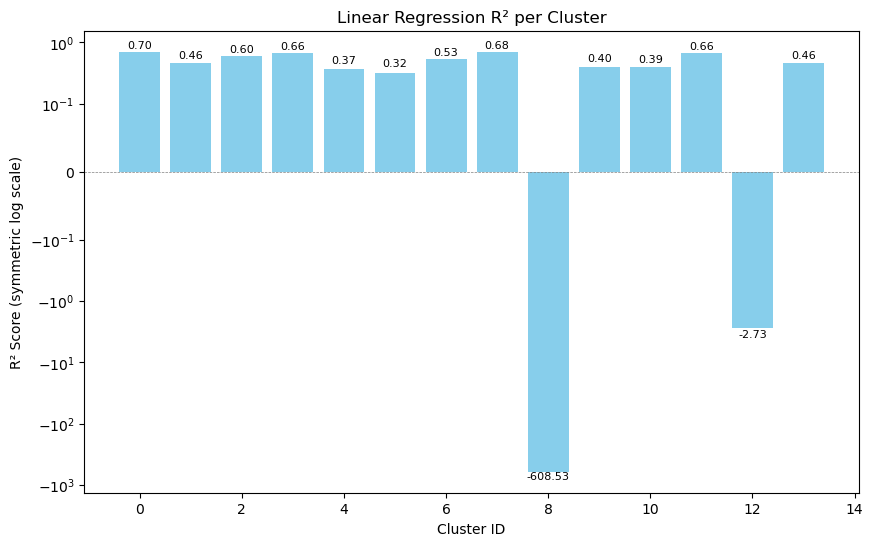

In [34]:
cluster_results_df = pd.DataFrame.from_dict(cluster_model_metrics, orient='index')
cluster_results_df.index.name = 'Cluster_ID'
cluster_results_df.reset_index(inplace=True)

plt.figure(figsize=(10,6))
bars = plt.bar(cluster_results_df['Cluster_ID'], cluster_results_df['r2'], color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("R² Score (symmetric log scale)")
plt.title("Linear Regression R² per Cluster")

# Use symmetric log scale to handle negative R2 values without skewing the graph
plt.yscale('symlog', linthresh=0.1)

# Annotate bars
for bar, score in zip(bars, cluster_results_df['r2']):
    y_pos = bar.get_height() + (0.05 if score >= 0 else -0.15)
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f"{score:.2f}", ha='center', va='bottom' if score >= 0 else 'top', fontsize=8)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.show()

# 5. Calculate Real Estate Deals

## 5.1 Finding the top 5 deals in each cluster

In [33]:
top_deals = []

for cluster_id, cluster_data in clustered_houses.items():
    model_info = cluster_price_models.get(cluster_id)
    if model_info is None:
        print(f"Skipping cluster {cluster_id}: no model available.")
        continue

    price_model = model_info['model']
    model_features = model_info['features']

    # Data is already normalized - use directly (no re-normalization)
    X_cluster = cluster_data[model_features]

    # Predict prices (in scaled space)
    predicted_prices = price_model.predict(X_cluster)

    # Compute discount in scaled space (predicted - actual; positive = underpriced)
    cluster_deals = cluster_data.copy()
    cluster_deals['Predicted_Price_Scaled'] = predicted_prices
    cluster_deals['Discount_Scaled'] = cluster_deals['Predicted_Price_Scaled'] - cluster_deals[TARGET]

    # Top 5 underpriced properties (largest positive delta)
    top_5 = cluster_deals.nlargest(5, 'Discount_Scaled').copy()
    top_5['Cluster_ID'] = cluster_id

    top_deals.append(top_5)

# Combine all clusters
top_deals_df = pd.concat(top_deals, axis=0)
top_deals_df.sort_values('Discount_Scaled', ascending=False, inplace=True)

# Join back to original_df to get actual prices for display
# The index is preserved through all transformations
top_deals_df['Actual_Price'] = original_df.loc[top_deals_df.index, 'Price'].values
top_deals_df.reset_index(drop=True, inplace=True)

top_deals_df[['Cluster_ID', 'Actual_Price', 'Discount_Scaled']]

,Cluster_ID,Actual_Price,Discount_Scaled
0,8,285000.0,65.377648
1,0,1328000.0,2.394228
2,0,420000.0,2.183029
3,0,899000.0,2.112863
4,0,1499000.0,1.211172
...,...,...,...
65,12,169900.0,0.163724
66,12,169900.0,0.163724
67,12,69900.0,0.060098
68,12,250000.0,0.053040
